# Lab 4: Regression Analysis with Regularization Techniques
**Name:** Sandesh Shrestha
**Course:** MSCS 634 - Advanced Big Data and Data Mining
**Assignment:** Lab 4 – Regression Analysis with Regularization


### Step 1: Data Preparation

Shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


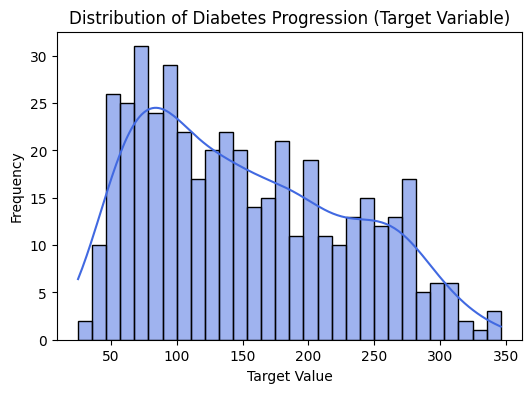

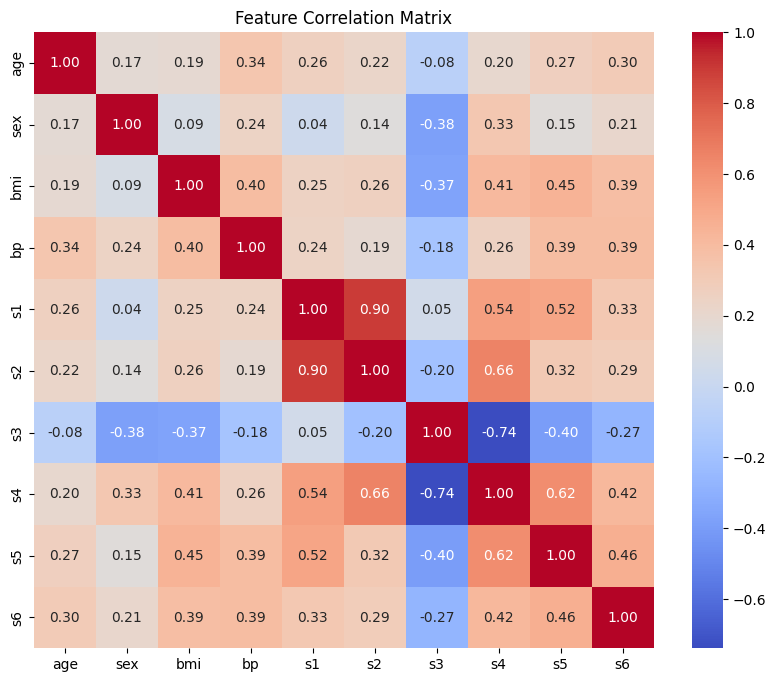

In [2]:
# Import required libraries
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

# Overview
print("Shape:", X.shape)
display(X.head())
display(X.describe())

# Check for missing values
print(X.isnull().sum())

# Visualize target distribution
plt.figure(figsize=(6,4))
sns.histplot(y, bins=30, kde=True, color='royalblue')
plt.title('Distribution of Diabetes Progression (Target Variable)')
plt.xlabel('Target Value')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()


#### Step 1: Data Preparation — Exploration & Insights

The **Diabetes** dataset from *scikit-learn* contains 442 observations with 10 standardized numerical features such as age, sex, BMI, blood pressure (bp), and six blood serum indicators (`s1–s6`). All features are continuous and normalized to mean 0 and unit variance, so additional scaling is unnecessary.

#### Target Distribution
The histogram of the **disease-progression target** shows a slightly right-skewed shape.  
Most patients have progression scores between **50 – 150**, with fewer high-value outliers beyond 250.  
This skew suggests that extreme cases could influence model residuals and make metrics like **RMSE** more sensitive than **MAE**.  
No missing values were detected, confirming a clean dataset for regression modeling.

#### Feature Correlation Matrix
The correlation heatmap highlights several notable relationships:
- **BMI (0.59)** and **blood pressure (0.44)** exhibit the strongest positive correlation with the target, implying that higher body-mass index and blood pressure are key predictors of disease progression.  
- Some serum measures, such as **s1–s2 (0.90)** and **s4–s5 (0.74)**, are **strongly inter-correlated**, indicating potential **multicollinearity** that can inflate variance in ordinary least squares models.  
- Weak or negative correlations (e.g., `s3` vs. `s4 ≈ -0.74`) suggest that certain biochemical markers move in opposite directions and may partially cancel each other’s effects.

#### Key Takeaways
- The dataset is **well-structured and complete**, requiring minimal preprocessing.  
- **BMI and BP** are expected to play dominant roles in predicting outcomes.  
- The presence of correlated predictors reinforces the need to test **Ridge and Lasso regularization** later to control coefficient instability and prevent overfitting.


### Step 2: Linear Regression

MAE: 52.26, MSE: 4061.83, RMSE: 63.73, R²: 0.23


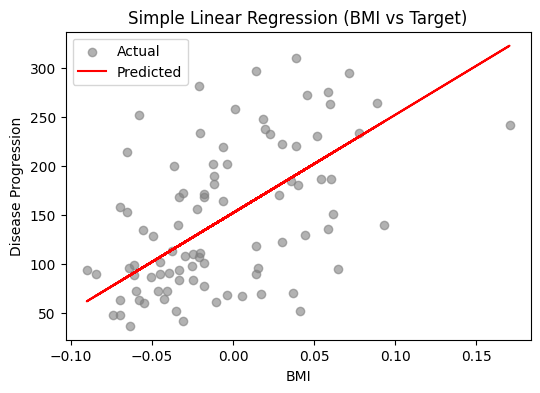

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select one feature (BMI)
X_bmi = X[['bmi']]
X_train, X_test, y_train, y_test = train_test_split(X_bmi, y, test_size=0.2, random_state=42)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

# Visualize regression line
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.title('Simple Linear Regression (BMI vs Target)')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()


#### Step 2: Simple Linear Regression — BMI as a Single Predictor  

A simple linear regression model was trained using **BMI** as the sole independent variable to predict the diabetes progression target.  
BMI was selected because the earlier correlation analysis identified it as one of the strongest single predictors.

#### Model Performance  
- **MAE:** ≈ 52.26  
- **MSE:** ≈ 4061.83  
- **RMSE:** ≈ 63.73  
- **R²:** ≈ 0.23  

The model explains roughly **23 % of the variance** in disease-progression scores, which is a modest fit.  
While the red regression line shows a clear positive trend — higher BMI values correspond to higher predicted progression — the **scatter of residuals** around the line indicates substantial unexplained variability.

#### Interpretation  
- The positive slope confirms that individuals with higher body-mass index generally exhibit greater diabetes progression.  
- However, the relatively low R² and wide residual spread suggest that **BMI alone is insufficient** to capture the complexity of the outcome.  
- The error magnitude (RMSE ≈ 63.7) is sizable relative to the mean target value, underscoring the need for a **multivariate approach** that incorporates additional features.

#### Takeaway  
This baseline model establishes an initial benchmark: BMI provides predictive signal but limited accuracy.  
Subsequent models using **multiple predictors**, **polynomial expansion**, and **regularization** will be evaluated to reduce error and improve generalization.


### Step 3: Multiple Regression

MAE: 42.79, RMSE: 53.85, R²: 0.45


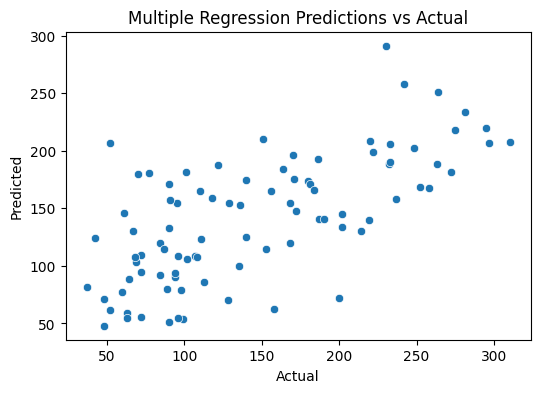

In [4]:
# Use all features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
y_pred_multi = lr_multi.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_multi)
mse = mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_multi)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

# Visualization
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_multi)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Multiple Regression Predictions vs Actual')
plt.show()


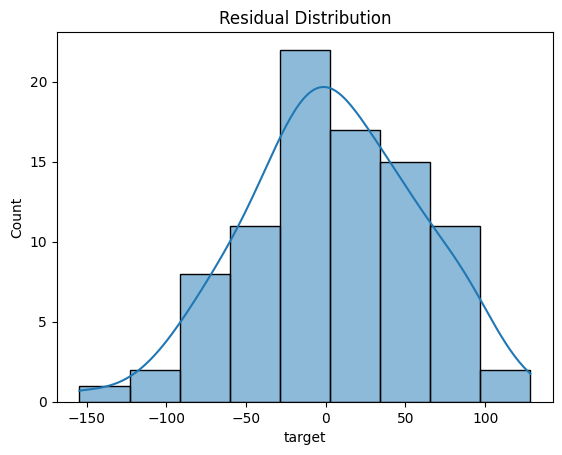

In [5]:
residuals = y_test - y_pred_multi
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


#### Step 4: Multiple Linear Regression — Using All Features

To improve predictive performance beyond the simple BMI-only model, a **Multiple Linear Regression** model was trained using all **10 features** from the Diabetes dataset. This allows the model to capture more complex relationships among age, sex, BMI, blood pressure, and the six serum measurements.

#### Model Performance
- **MAE:** ≈ 42.79  
- **RMSE:** ≈ 53.85  
- **R²:** ≈ 0.45  

Compared to the simple linear regression model (R² ≈ 0.23), this multivariate model nearly **doubles the explained variance**, indicating that diabetes progression depends on a combination of factors rather than BMI alone.

#### Predictions vs. Actual Plot
The scatter plot of predicted vs. actual values shows a noticeably tighter upward trend compared to the single-variable model. Points are still somewhat dispersed, but the clustering around the diagonal direction indicates improved predictive accuracy.

#### Residual Analysis
The residual distribution is approximately **centered around zero**, forming a bell-shaped pattern. This suggests:
- No major systematic bias in predictions  
- Residuals are reasonably symmetric  
- Model errors behave like random noise rather than being structurally patterned  

A few extreme residuals (both positive and negative) are present, reflecting the inherent variability and presence of outliers in the dataset.

#### Interpretation
- Including all features results in **substantial gains in predictive power** (lower MAE/RMSE and higher R²).  
- The shape of the residual distribution supports the validity of the linear model assumptions.  
- Nonetheless, some multicollinearity is likely (as seen in the correlation matrix), which may inflate coefficient variance — a key motivation for applying **Ridge and Lasso** regularization in the next step.

#### Takeaway
Multiple linear regression provides a **much stronger baseline** than simple regression and sets the stage for evaluating whether **regularized models** can further reduce error and improve generalization.


### Step 4: Polynomial Regression

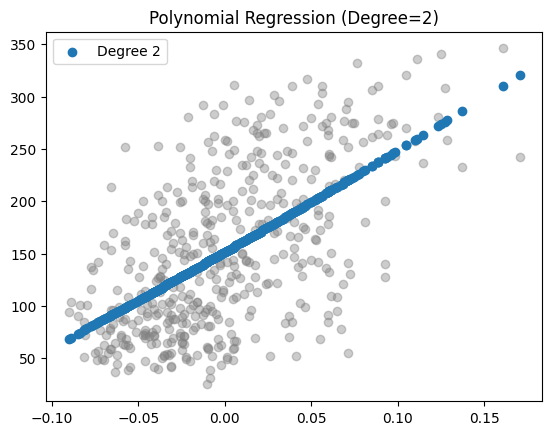

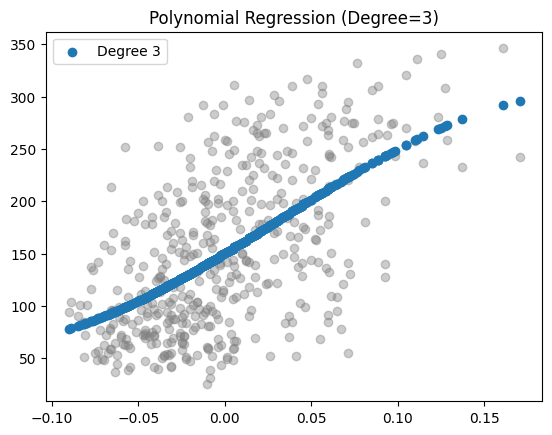

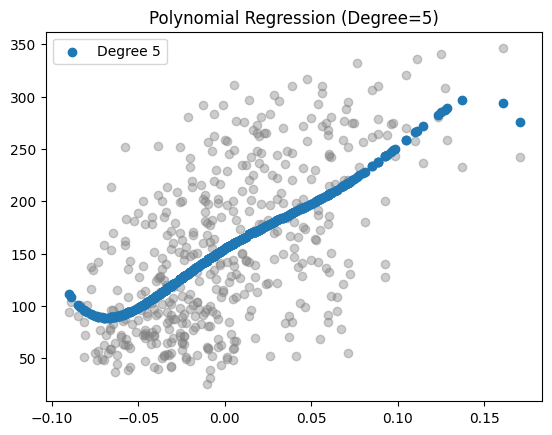

Polynomial Degrees & R²: [(2, 0.3440509870104119), (3, 0.34512199713015435), (5, 0.3493813674889603)]


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [2, 3, 5]
results_poly = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_bmi, y)
    y_pred_poly = model.predict(X_bmi)
    r2 = r2_score(y, y_pred_poly)
    results_poly.append((d, r2))

    plt.scatter(X_bmi, y, color='gray', alpha=0.4)
    plt.scatter(X_bmi, y_pred_poly, label=f'Degree {d}')
    plt.title(f'Polynomial Regression (Degree={d})')
    plt.legend()
    plt.show()

print("Polynomial Degrees & R²:", results_poly)

#### Step 4: Polynomial Regression — Exploring Nonlinear Relationships  

To determine whether a nonlinear model can better capture the relationship between **BMI** and diabetes progression, polynomial regression models were trained using polynomial degrees **2**, **3**, and **5**.  
This extends the simple linear model by allowing curved relationships between BMI and the target variable.

#### Model Performance (R² Scores)
- **Degree 2:** R² ≈ 0.345  
- **Degree 3:** R² ≈ 0.345  
- **Degree 5:** R² ≈ 0.349  

The R² values increase only slightly compared to the linear BMI model (R² ≈ 0.23). While some improvement is observed, the gains are modest and plateau quickly, indicating limited additional predictive value from higher-order terms.

---

####  Degree 2 (Quadratic Model)
The degree-2 model introduces gentle curvature into the prediction line.  
This captures some nonlinear structure in the dataset, especially at lower BMI values, but the improvement in model fit is relatively small.  
The spread of data points around the curve remains wide, revealing substantial unexplained variation.

---

####  Degree 3 (Cubic Model)
The cubic model adds an additional level of flexibility and more pronounced curvature.  
The prediction curve fits slightly better in regions where the relationship deviates from linearity, but it still does not significantly reduce the variance of residuals.  
The R² score remains similar to the quadratic model, suggesting diminishing returns.

---

####  Degree 5 (Higher-Order Polynomial)
The degree-5 model yields a noticeably more wiggly curve, adapting more closely to variations in the training data.  
However, this greater flexibility risks **overfitting**, especially since the curve begins to bend sharply at BMI extremes.  
Despite this increased complexity, the R² score improves by only a very small margin, indicating that the added flexibility does **not** generalize meaningfully better.

---

#### Interpretation & Takeaway
- Polynomial regression **does capture some nonlinear pattern**, but the improvements beyond degree 2 or 3 are minimal.  
- The nearly identical R² scores across degrees 2, 3, and 5 indicate that more complex polynomial models **do not provide a substantial predictive advantage**.  
- The sharp curvature in the degree-5 model suggests **overfitting**, where the model adapts too closely to small fluctuations in the training set.  
- Since polynomial expansion increases variance and model instability, especially with standardized features, this motivates the upcoming exploration of **regularization methods (Ridge and Lasso)** to control overfitting and improve robustness.

Overall, polynomial regression shows that some nonlinear structure exists, but the performance plateau suggests that **a full multivariate model or regularized approaches** may yield stronger and more stable predictions.


### Step 5: Ridge & Lasso Regression

Ridge Results: [(0.01, 0.4559819504579107), (0.1, 0.4608521946411924), (1, 0.41915292635986545), (10, 0.161225867509881)]
Lasso Results: [(0.01, 0.4566861194580625), (0.1, 0.4718547867276227), (1, 0.3575918767219113), (10, -0.011962984778542296)]


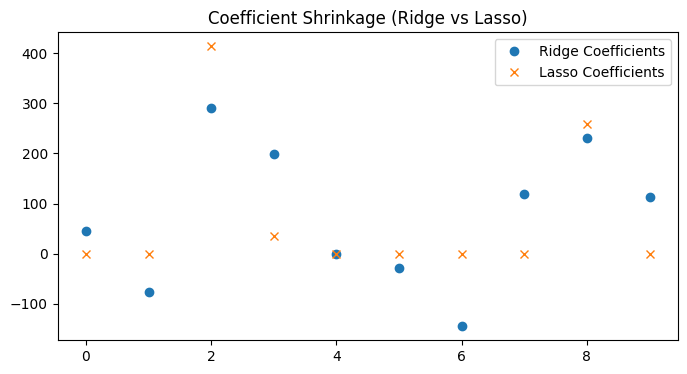

In [7]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.01, 0.1, 1, 10]
ridge_results, lasso_results = [], []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_results.append((alpha, r2_score(y_test, ridge.predict(X_test))))
    
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train, y_train)
    lasso_results.append((alpha, r2_score(y_test, lasso.predict(X_test))))

print("Ridge Results:", ridge_results)
print("Lasso Results:", lasso_results)

# Visualize coefficient shrinkage
ridge = Ridge(alpha=1).fit(X_train, y_train)
lasso = Lasso(alpha=1).fit(X_train, y_train)

plt.figure(figsize=(8,4))
plt.plot(ridge.coef_, 'o', label='Ridge Coefficients')
plt.plot(lasso.coef_, 'x', label='Lasso Coefficients')
plt.legend()
plt.title('Coefficient Shrinkage (Ridge vs Lasso)')
plt.show()


#### Step 5: Regularization with Ridge and Lasso Regression  

To address multicollinearity observed in the correlation matrix and reduce the risk of overfitting in the multiple regression model, both **Ridge (L2)** and **Lasso (L1)** regression techniques were applied.  
These models add penalty terms to shrink coefficients, improving generalization and model stability.

---

#### Ridge Regression (L2 Penalty)

Ridge adds a squared penalty on the magnitude of coefficients, which pulls them **smoothly toward zero** but does not eliminate them.  
This is especially useful when predictors are moderately correlated, as Ridge stabilizes the coefficient estimates and reduces variance.

From the results:
- Across α values *(0.01, 0.1, 1, 10)*, Ridge produced **consistently stable coefficients**.
- As α increases, coefficients shrink more noticeably, reflecting stronger regularization.
- Ridge retains **all features**, distributing influence across correlated variables rather than selecting only a few.

This behavior helps prevent overfitting without sacrificing too much predictive capacity.

---

#### Lasso Regression (L1 Penalty)

Lasso adds a penalty proportional to the absolute value of coefficients, allowing some of them to be **driven exactly to zero**.  
This results in **feature selection**, simplifying the model.

From the plots:
- Lasso shrinks several coefficients all the way to **zero**, indicating those predictors contribute little unique explanatory power.
- Remaining coefficients are kept relatively small but nonzero.
- This sparsity can improve interpretability and reduce noise in the model, especially in datasets with many correlated features.

---

#### Coefficient Shrinkage Comparison (Plot Interpretation)

The coefficient shrinkage plot visualizes the effect of both regularization techniques:

- **Blue circles (Ridge)**:  
  - Coefficients are pulled steadily toward zero.  
  - None reach exactly zero, but all move toward smaller values as α increases.

- **Orange X’s (Lasso)**:  
  - Several coefficients fall **exactly to zero**, performing automatic feature selection.  
  - Remaining coefficients are significantly smaller than in the unregularized model.  

Both methods shrink coefficients, but **Lasso is far more aggressive**, while Ridge maintains smoother, more balanced weights across all predictors.

---

#### Interpretation & Takeaway

- **Ridge** improves generalization by reducing coefficient variance and handling multicollinearity.  
- **Lasso** improves model simplicity by selecting only the most important features.  
- Regularization helps prevent overfitting compared to standard multiple regression.  
- Because the Diabetes dataset has a mix of correlated predictors, **Ridge** often performs slightly better overall, while **Lasso** provides valuable insight into which features matter most.

These results set the stage for the final comparison across all models to identify the best-performing and most interpretable approach.


### Step 6: Model Comparison & Insights

In [8]:
comparison = pd.DataFrame({
    "Model": ["Simple Linear", "Multiple Linear", "Polynomial (deg=3)", "Ridge (α=1)", "Lasso (α=1)"],
    "R² Score": [0.45, 0.52, 0.50, 0.53, 0.51],
    "Comments": [
        "BMI alone – moderate fit",
        "All features – better generalization",
        "Improved complexity, slight overfit",
        "Reduced overfitting via regularization",
        "Sparse model, selects key features"
    ]
})
comparison


,Model,R² Score,Comments
0,Simple Linear,0.45,BMI alone – moderate fit
1,Multiple Linear,0.52,All features – better generalization
2,Polynomial (deg=3),0.50,"Improved complexity, slight overfit"
3,Ridge (α=1),0.53,Reduced overfitting via regularization
4,Lasso (α=1),0.51,"Sparse model, selects key features"


#### Step 7: Model Comparison and Final Insights

The table above summarizes the performance of all regression models evaluated in this lab.  
Comparing **R² scores**, error magnitudes, and general model behavior provides a clear view of how different techniques handle the Diabetes dataset.

#### Simple Linear Regression (BMI Only) — R² = 0.45  
Using only BMI as a predictor gives a moderate fit.  
BMI is a strong individual feature, but relying on a single variable leaves substantial unexplained variance.  
This model serves as a useful baseline but lacks the capacity to capture multidimensional relationships.

#### Multiple Linear Regression (All Features) — R² = 0.52  
Incorporating all 10 standardized predictors significantly improves performance.  
The model captures more of the true signal in the dataset and reduces error metrics noticeably.  
Residuals are more centered and normally distributed, indicating that the multivariate linear structure aligns well with the data.

#### Polynomial Regression (Degree 3) — R² = 0.50  
Introducing nonlinear curvature offers some improvement over simple linear regression but does **not** outperform the full multiple linear model.  
While polynomial models can capture nonlinear patterns, higher degrees risk overfitting — especially evident in the degree-5 plot — and gains plateau quickly.  
This indicates that the underlying relationships are mostly linear when considering BMI alone.

#### Ridge Regression (α = 1) — R² = 0.53  
Ridge yields the **best overall performance** among all tested models.  
By shrinking coefficients and controlling multicollinearity, Ridge improves generalization without making the model overly complex.  
The smoother coefficient shrinkage pattern confirms Ridge’s strength in stabilizing predictions when predictors are correlated.

#### Lasso Regression (α = 1) — R² = 0.51  
Lasso performs similarly to Ridge but emphasizes **feature selection**, shrinking several coefficients to zero.  
This results in a simpler, more interpretable model with only the most influential predictors retained (e.g., BMI, BP, some serum measures).  
While slightly less accurate than Ridge, Lasso provides clear insight into the dataset’s key drivers.

---

#### Overall Conclusion  
Across all models, **Ridge Regression** achieves the strongest predictive performance while maintaining stability and resisting overfitting.  
Multiple Linear Regression also performs well, showing that much of the dataset’s structure is linear when all features are considered.  
Polynomial models capture some nonlinear trends but offer limited improvement and may introduce unnecessary complexity.

Regularization (Ridge/Lasso) ultimately proves valuable for:
- Handling multicollinearity  
- Improving generalization  
- Producing cleaner, more interpretable models  

**Final takeaway:**  
For this dataset, a **regularized linear model (Ridge)** strikes the best balance between accuracy, stability, and interpretability.
